# Australia Weather Dataset: Missing-Data Analysis & Preprocessing Pipeline

Goal: turn the raw *Rain in Australia* data (`weatherAUS.csv`, ~145k daily observations from 49 weather stations)
into a clean, fully numeric table that is ready for predicting **`RainTomorrow`**.

Pipeline:
1. Load and profile the data
2. Diagnose **where** and **when** values are missing
3. Remove stations whose records are too incomplete to trust
4. Impute numeric features (KNN) and categorical features (per-station forward/back fill)
5. Encode categoricals, validate, and export

Download the data from Kaggle ("Rain in Australia") and place `weatherAUS.csv` next to this notebook,
or set the `WEATHER_CSV` environment variable. In Google Colab the notebook mounts Drive automatically.

## 1. Setup

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ---------------- configuration ----------------
DATA_PATH = Path(os.environ.get("WEATHER_CSV", "weatherAUS.csv"))
FIG_DIR = Path("images")        # figures are saved here (used by the README)
RESULTS_DIR = Path("results")   # metrics are saved here
OUT_DIR = Path("data")          # cleaned dataset is saved here
SAVE_FIGS = True
SHOW_ALL_FEATURE_PLOTS = False  # True = one plot per feature (~40 extra figures)
MISSING_THRESHOLD = 0.80        # drop stations with any column missing more than this share
KNN_NEIGHBORS = 5
RANDOM_STATE = 42

# Optional: mount Google Drive when running in Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
    # change this folder to wherever you stored weatherAUS.csv
    DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/weatherAUS.csv")
except ImportError:
    pass

for d in (FIG_DIR, RESULTS_DIR, OUT_DIR):
    d.mkdir(exist_ok=True)

summary = {}  # collected metrics, saved to results/preprocessing_summary.json at the end

import gc
from sklearn import set_config
set_config(working_memory=256)  # keep KNN distance chunks small so it also runs on low-memory machines

def transform_in_chunks(imputer, X, chunk=10_000):
    # imputer.transform in row chunks: same result as one big call, bounded memory
    return np.vstack([imputer.transform(X[i:i + chunk]) for i in range(0, len(X), chunk)])

def save_fig(name):
    if SAVE_FIGS:
        plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 2. Load and profile the data

In [2]:
weather_df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
# Sorting by station then date matters later (time-aware filling, time plots)
weather_df = weather_df.sort_values(["Location", "Date"]).reset_index(drop=True)

print(f"Dataset dimensions: {weather_df.shape}")
print(f"Stations: {weather_df['Location'].nunique()}")
print(f"Date range: {weather_df['Date'].min().date()} to {weather_df['Date'].max().date()}")
print()
print(weather_df.dtypes)

summary["raw_rows"], summary["raw_columns"] = weather_df.shape
summary["raw_locations"] = int(weather_df["Location"].nunique())

Dataset dimensions: (145460, 23)
Stations: 49
Date range: 2007-11-01 to 2017-06-25

Date             datetime64[us]
Location                    str
MinTemp                 float64
MaxTemp                 float64
Rainfall                float64
Evaporation             float64
Sunshine                float64
WindGustDir                 str
WindGustSpeed           float64
WindDir9am                  str
WindDir3pm                  str
WindSpeed9am            float64
WindSpeed3pm            float64
Humidity9am             float64
Humidity3pm             float64
Pressure9am             float64
Pressure3pm             float64
Cloud9am                float64
Cloud3pm                float64
Temp9am                 float64
Temp3pm                 float64
RainToday                   str
RainTomorrow                str
dtype: object


## 3. Missing-value overview

The percentage is computed directly from the data (the original notebook hard-coded the row count `145460`).

Sunshine         48.01
Evaporation      43.17
Cloud3pm         40.81
Cloud9am         38.42
Pressure9am      10.36
Pressure3pm      10.33
WindDir9am        7.26
WindGustDir       7.10
WindGustSpeed     7.06
Humidity3pm       3.10
WindDir3pm        2.91
Temp3pm           2.48
RainTomorrow      2.25
Rainfall          2.24
RainToday         2.24
WindSpeed3pm      2.11
Humidity9am       1.82
WindSpeed9am      1.21
Temp9am           1.21
MinTemp           1.02
MaxTemp           0.87
Date              0.00
Location          0.00


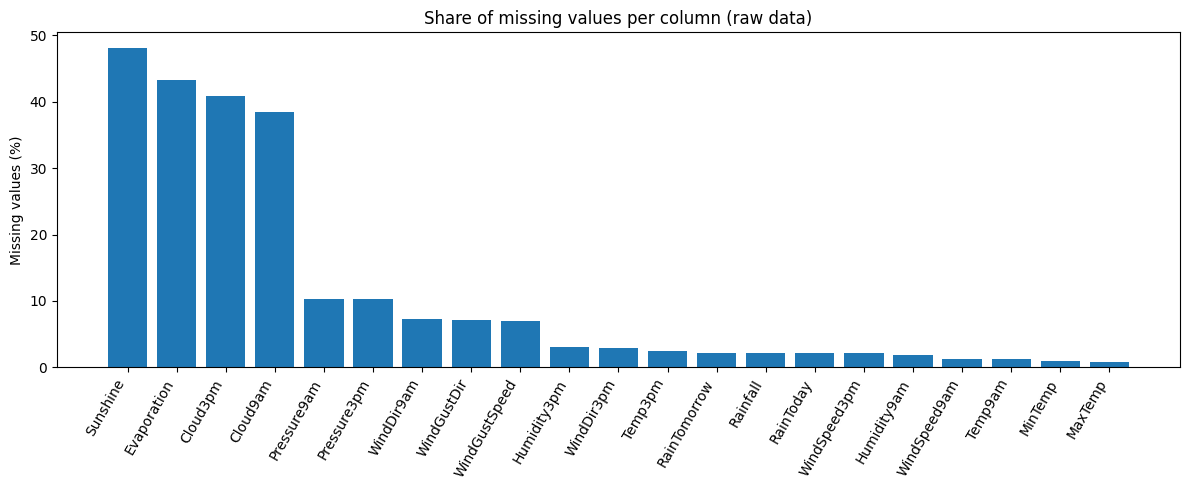

In [3]:
nan_pct = (weather_df.isna().mean() * 100).sort_values(ascending=False)
print(nan_pct.round(2).to_string())
summary["nan_pct_by_column_raw"] = nan_pct.round(3).to_dict()

nan_nonzero = nan_pct[nan_pct > 0]
plt.figure(figsize=(12, 5))
plt.bar(nan_nonzero.index, nan_nonzero.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Missing values (%)")
plt.title("Share of missing values per column (raw data)")
plt.tight_layout()
save_fig("00_missing_by_column_raw")
plt.show()

## 4. Where is data missing? (by station)

Missingness is not spread evenly. It is concentrated in a few columns (`Evaporation`, `Sunshine`, `Cloud*`, `Pressure*`)
and, within them, in particular stations.

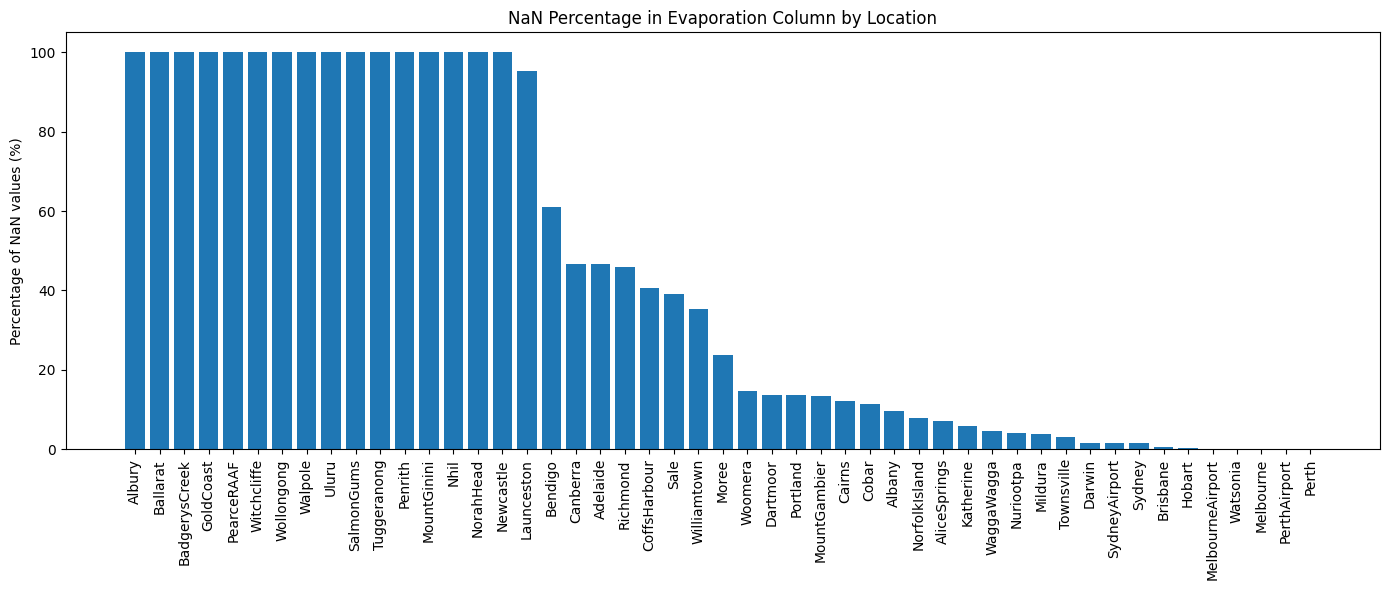

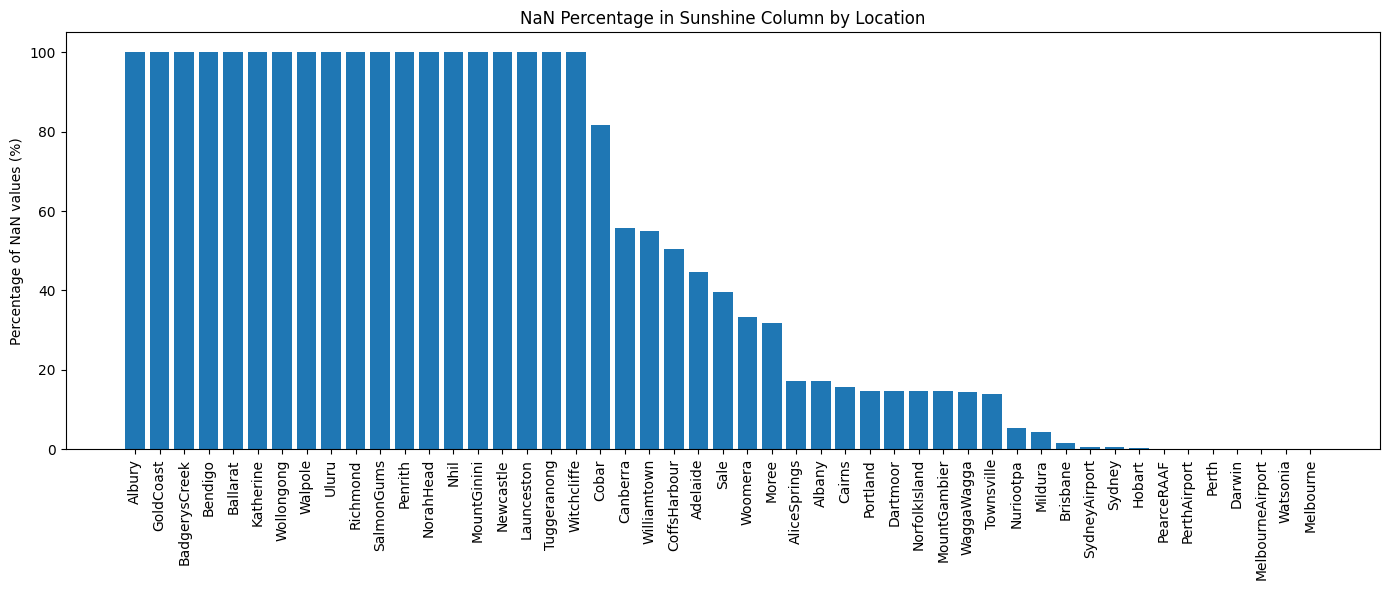

In [4]:
def nan_pct_by_location(df, feature):
    """Percent of missing values of `feature` for every Location (no deprecated groupby.apply)."""
    return df[feature].isna().groupby(df["Location"]).mean().mul(100).sort_values(ascending=False)

def plot_nan_by_location(df, feature, suffix="", fname=None):
    s = nan_pct_by_location(df, feature)
    plt.figure(figsize=(14, 6))
    plt.bar(s.index, s.values)
    plt.xticks(rotation=90)
    plt.ylabel("Percentage of NaN values (%)")
    plt.title(f"NaN Percentage in {feature} Column by Location{suffix}")
    plt.tight_layout()
    if fname:
        save_fig(fname)
    plt.show()

plot_nan_by_location(weather_df, "Evaporation", fname="01_evaporation_nan_by_location_raw")
plot_nan_by_location(weather_df, "Sunshine", fname="02_sunshine_nan_by_location_raw")

if SHOW_ALL_FEATURE_PLOTS:
    for feature in [c for c in weather_df.columns if c not in ("Location", "Date")]:
        plot_nan_by_location(weather_df, feature)

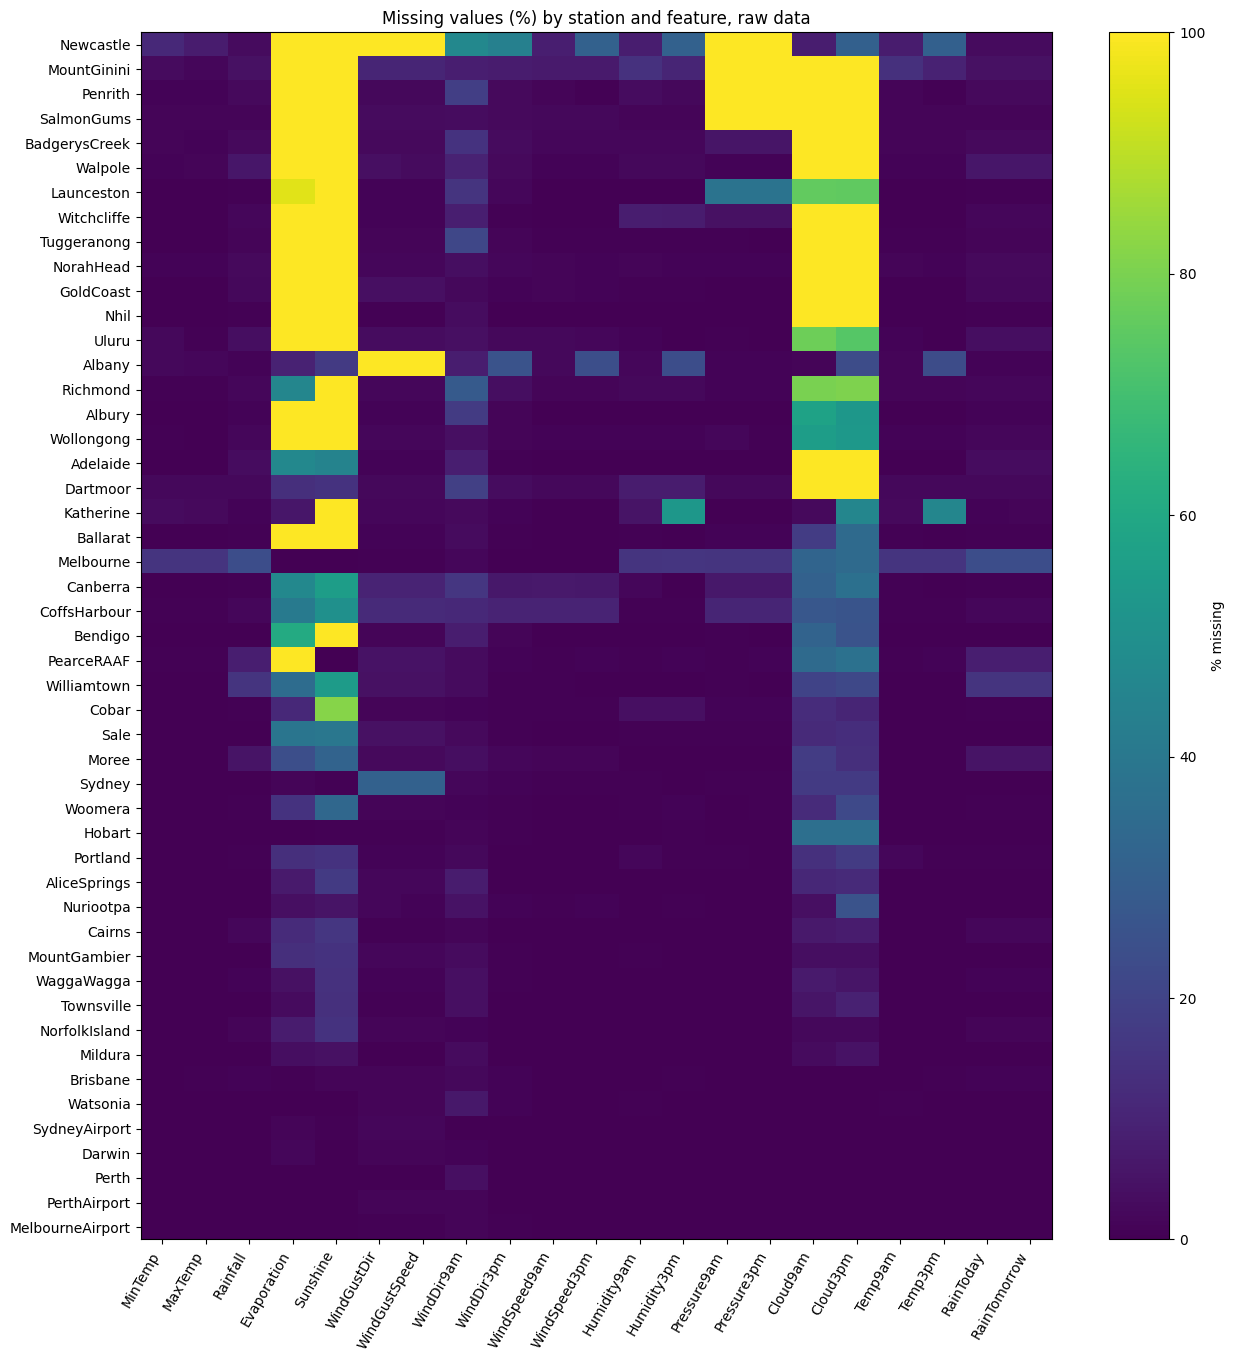

In [5]:
# One picture for every feature x station: percent missing heatmap
def plot_nan_heatmap(df, title, fname):
    m = df.drop(columns=["Date"]).drop(columns=["Location"]).isna().groupby(df["Location"]).mean() * 100
    m = m.loc[m.mean(axis=1).sort_values(ascending=False).index]
    m = m.loc[:, m.max() > 0]
    fig, ax = plt.subplots(figsize=(13, max(5, 0.28 * len(m))))
    im = ax.imshow(m.values, aspect="auto", cmap="viridis", vmin=0, vmax=100)
    ax.set_xticks(range(m.shape[1])); ax.set_xticklabels(m.columns, rotation=60, ha="right")
    ax.set_yticks(range(m.shape[0])); ax.set_yticklabels(m.index)
    fig.colorbar(im, ax=ax, label="% missing")
    ax.set_title(title)
    plt.tight_layout()
    save_fig(fname)
    plt.show()

plot_nan_heatmap(weather_df, "Missing values (%) by station and feature, raw data", "03_missing_heatmap_raw")

## 5. When is data missing? (over time)

If values were missing at random, the indicator would flicker evenly. Instead, whole stretches vanish:
stations stop reporting an instrument. That matters for the imputation strategy.

*Fix:* the original code filtered Canberra/Williamtown but titled the second plot "Melbourne",
and plotted the series as sloped lines. This version takes the station as a parameter and uses step plots.

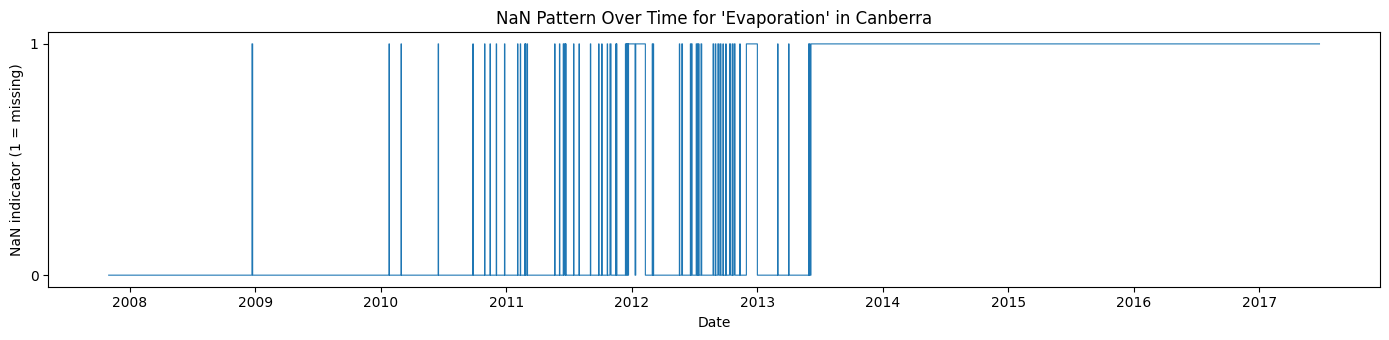

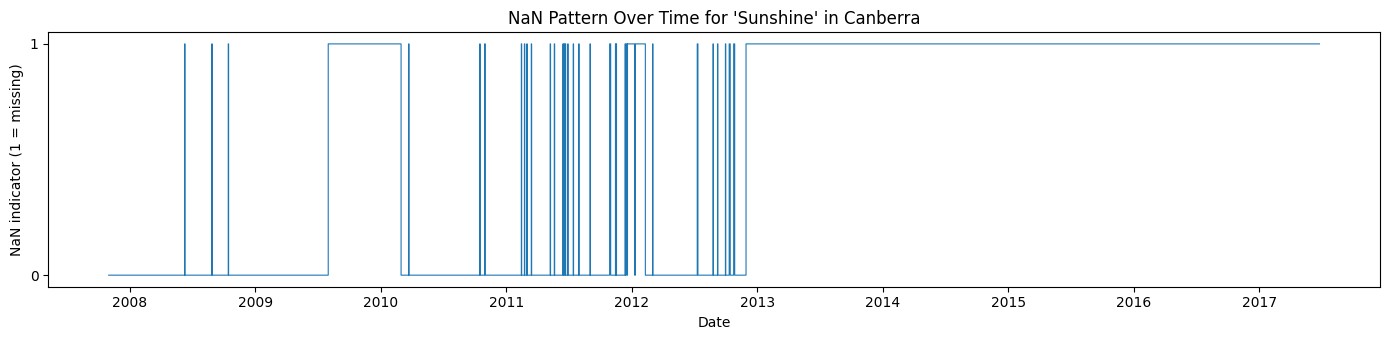

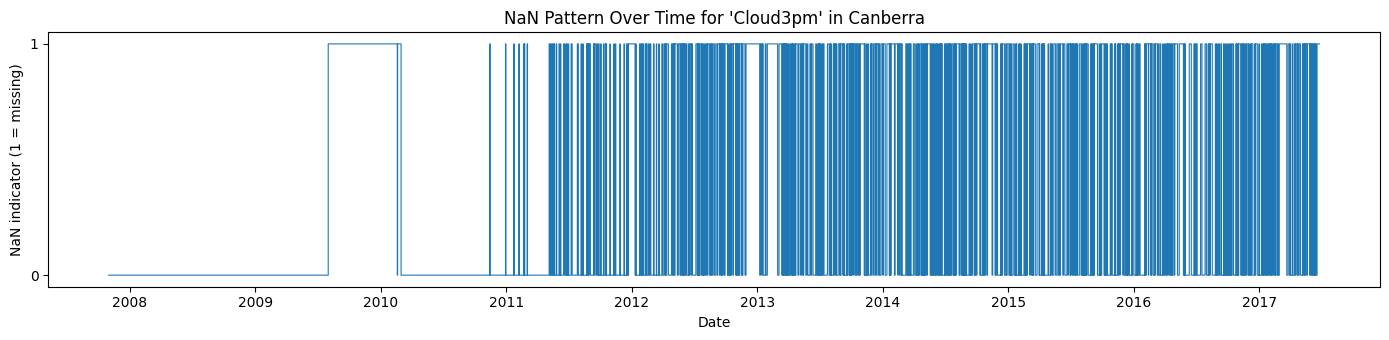

In [6]:
def plot_nan_over_time(df, location, features, stage=""):
    sub = df[df["Location"] == location]
    for feature in features:
        plt.figure(figsize=(14, 3.5))
        plt.plot(sub["Date"], sub[feature].isna().astype(int), linewidth=0.8, drawstyle="steps-post")
        plt.title(f"NaN Pattern Over Time for '{feature}' in {location}{stage}")
        plt.xlabel("Date")
        plt.ylabel("NaN indicator (1 = missing)")
        plt.yticks([0, 1])
        plt.tight_layout()
        tag = "_" + stage.strip(" ()").lower().replace(" ", "_") if stage else ""
        save_fig(f"nan_over_time_{location}_{feature}{tag}")
        plt.show()

KEY_FEATURES = ["Evaporation", "Sunshine", "Cloud3pm"]
all_features = [c for c in weather_df.columns if c not in ("Location", "Date")]
plot_nan_over_time(weather_df, "Canberra", all_features if SHOW_ALL_FEATURE_PLOTS else KEY_FEATURES)

## 6. Remove stations with unusable records

A station is dropped if **any** column is missing more than 80% of the time. For those stations a model would learn
from imputed values rather than measurements.

In [7]:
nan_frac_by_loc = weather_df.drop(columns="Location").isna().groupby(weather_df["Location"]).mean()
bad_locations = nan_frac_by_loc.index[(nan_frac_by_loc > MISSING_THRESHOLD).any(axis=1)].tolist()

weather_df_clean = weather_df[~weather_df["Location"].isin(bad_locations)].copy()

print("Locations before:", weather_df["Location"].nunique())
print("Locations removed:", bad_locations)
print("Locations remaining:", weather_df_clean["Location"].nunique())
print(f"Rows: {len(weather_df):,} -> {len(weather_df_clean):,} "
      f"({100 * len(weather_df_clean) / len(weather_df):.1f}% kept)")

summary.update(
    locations_removed=bad_locations,
    locations_remaining=int(weather_df_clean["Location"].nunique()),
    rows_after_location_removal=int(len(weather_df_clean)),
)

Locations before: 49
Locations removed: ['Adelaide', 'Albany', 'Albury', 'BadgerysCreek', 'Ballarat', 'Bendigo', 'Cobar', 'Dartmoor', 'GoldCoast', 'Katherine', 'Launceston', 'MountGinini', 'Newcastle', 'Nhil', 'NorahHead', 'PearceRAAF', 'Penrith', 'Richmond', 'SalmonGums', 'Tuggeranong', 'Uluru', 'Walpole', 'Witchcliffe', 'Wollongong']
Locations remaining: 25
Rows: 145,460 -> 77,031 (53.0% kept)


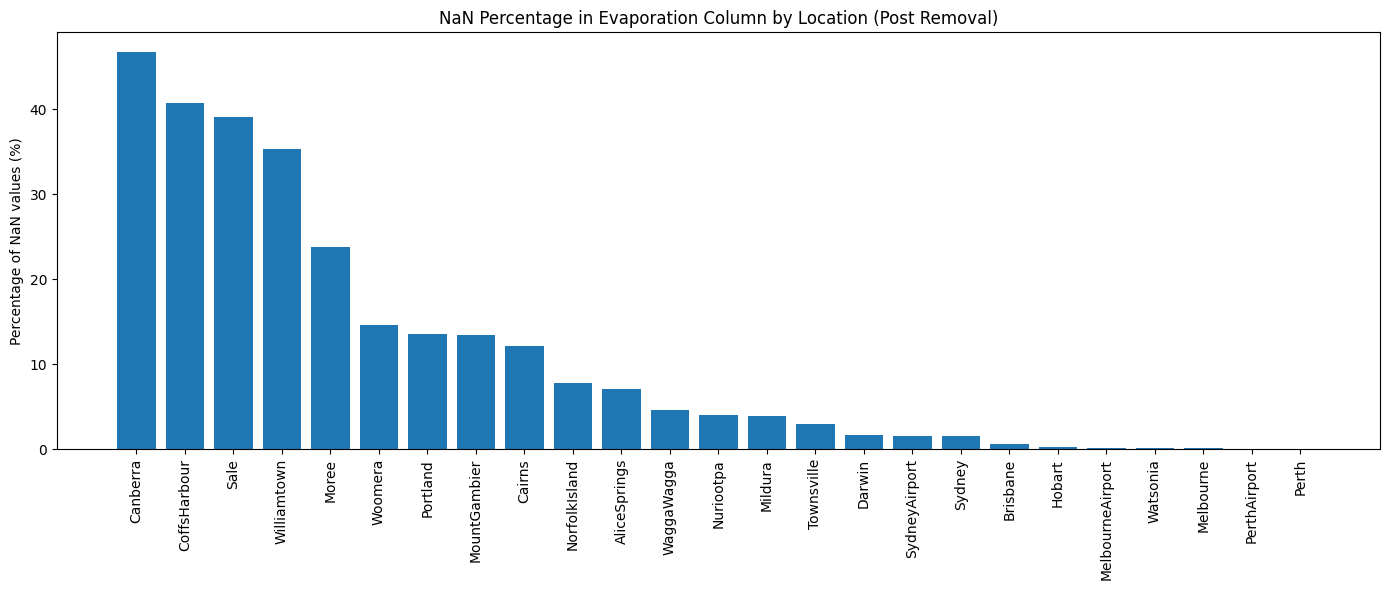

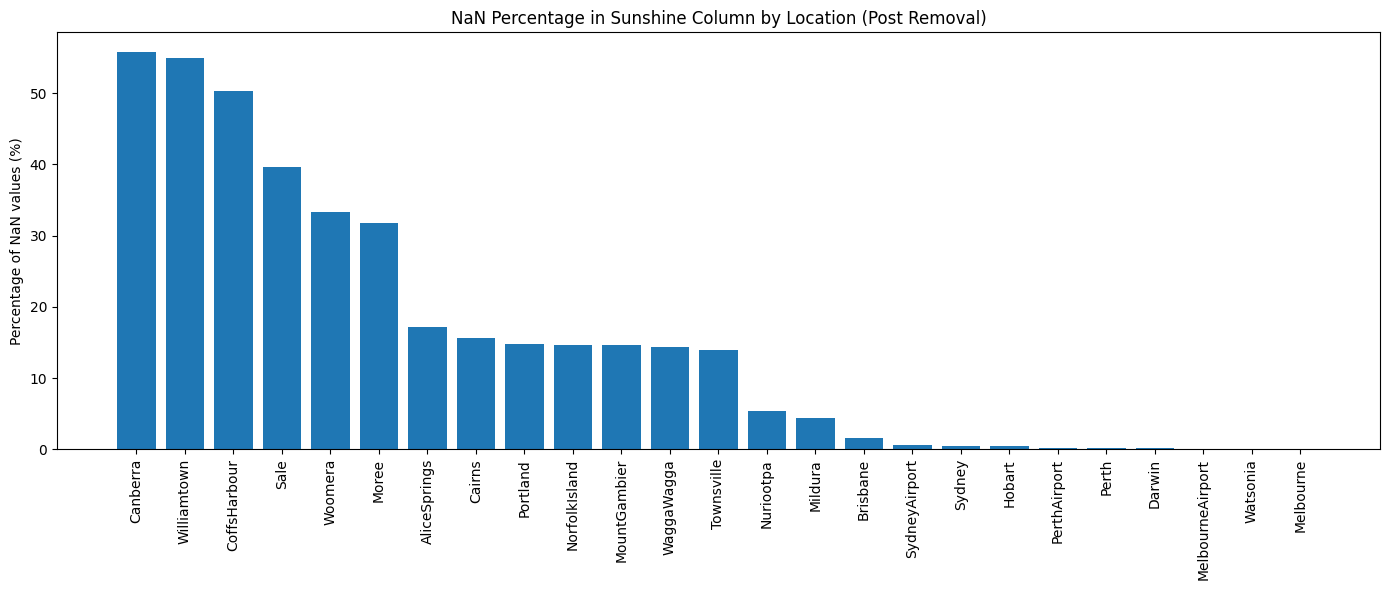

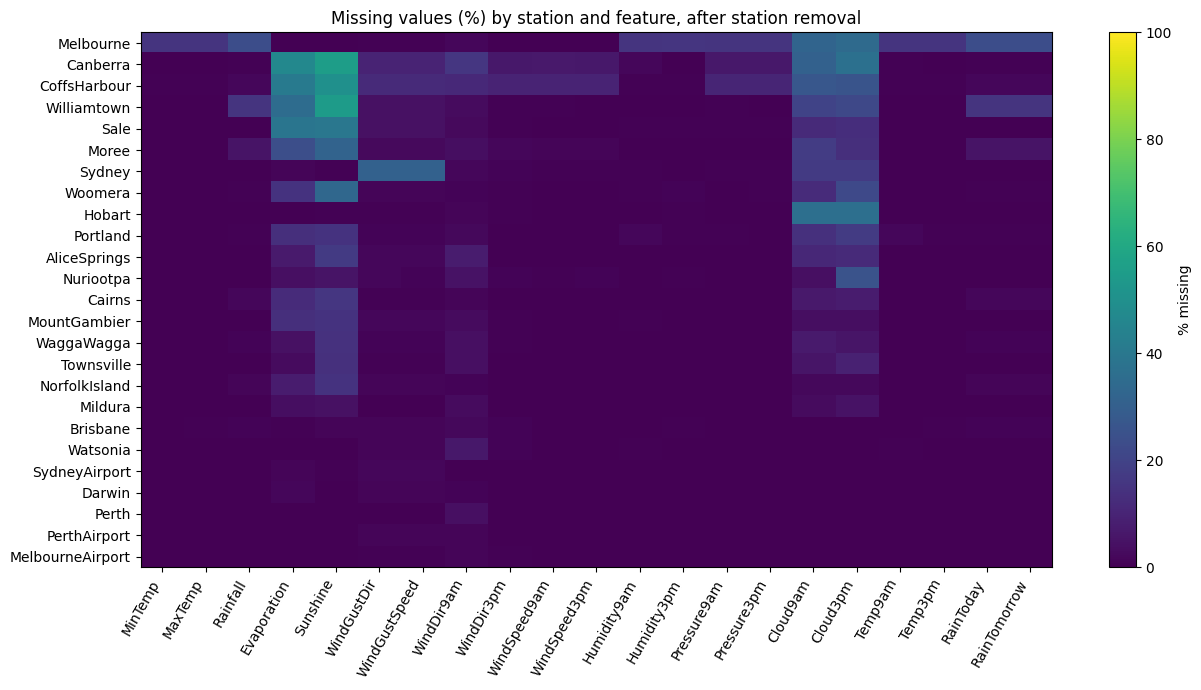

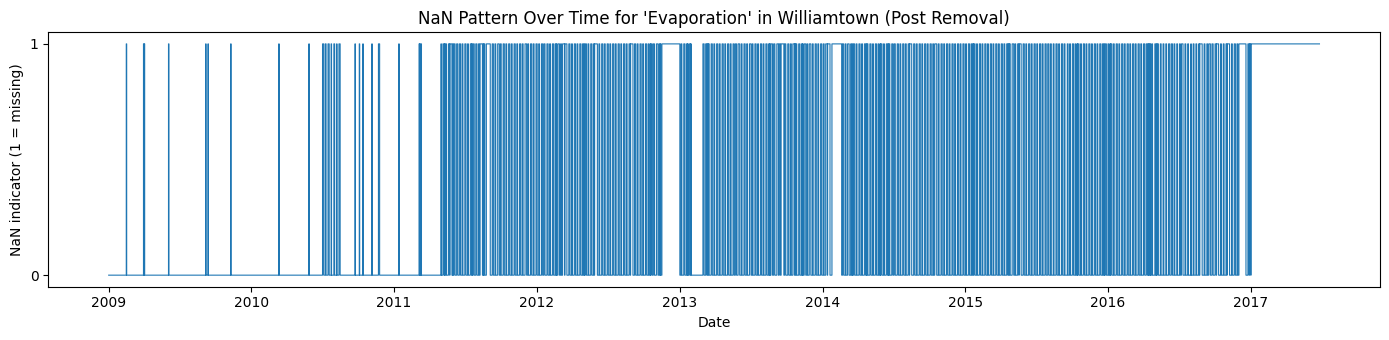

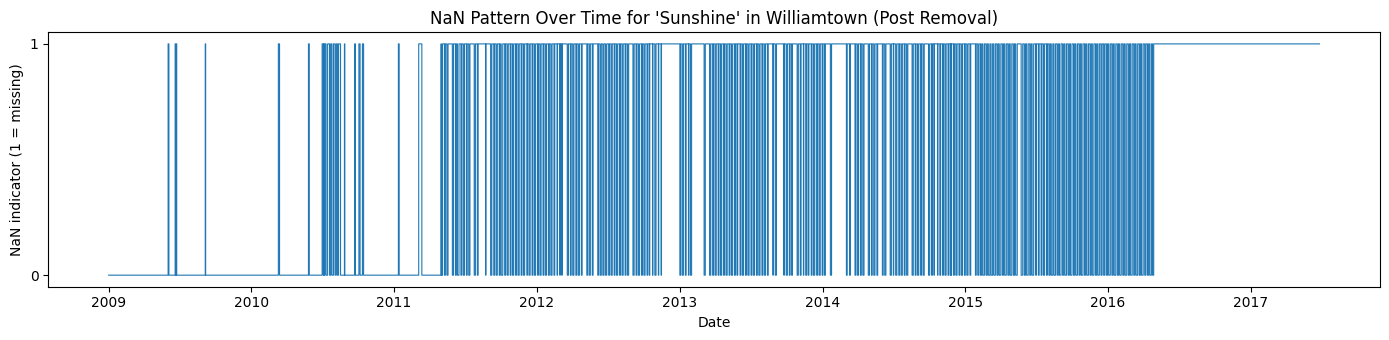

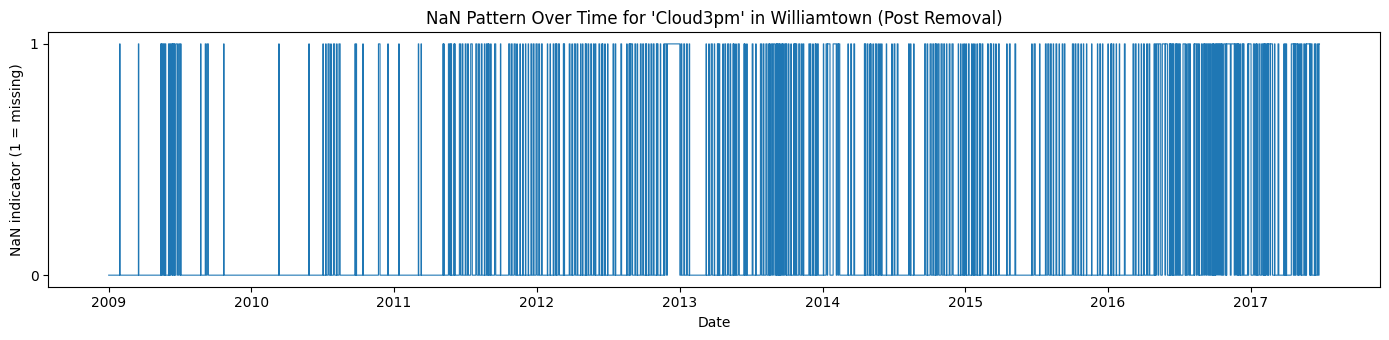

In [8]:
plot_nan_by_location(weather_df_clean, "Evaporation", " (Post Removal)", "04_evaporation_nan_by_location_clean")
plot_nan_by_location(weather_df_clean, "Sunshine", " (Post Removal)", "05_sunshine_nan_by_location_clean")
plot_nan_heatmap(weather_df_clean, "Missing values (%) by station and feature, after station removal", "06_missing_heatmap_clean")

if SHOW_ALL_FEATURE_PLOTS:
    for feature in [c for c in weather_df_clean.columns if c not in ("Location", "Date")]:
        plot_nan_by_location(weather_df_clean, feature, " (Post Removal)")

plot_nan_over_time(weather_df_clean, "Williamtown",
                   all_features if SHOW_ALL_FEATURE_PLOTS else KEY_FEATURES, stage=" (Post Removal)")

## 7. Handle the target

`RainTomorrow` is what we want to predict, so it should never be *invented*. The original notebook forward-filled it
from neighbouring rows. Here rows without a label are dropped instead.

In [9]:
n_before = len(weather_df_clean)
weather_df_clean = weather_df_clean.dropna(subset=["RainTomorrow"]).reset_index(drop=True)
print(f"Dropped {n_before - len(weather_df_clean):,} rows with no RainTomorrow label; {len(weather_df_clean):,} remain")
summary["rows_dropped_missing_target"] = int(n_before - len(weather_df_clean))

Dropped 1,708 rows with no RainTomorrow label; 75,323 remain


## 8. Split numeric and categorical features

In [10]:
wind_cols = ["WindGustDir", "WindDir9am", "WindDir3pm"]
binary_cols = ["RainToday", "RainTomorrow"]
categorical_cols = ["Location"] + wind_cols + binary_cols

numeric_cols = [c for c in weather_df_clean.columns if c not in categorical_cols + ["Date"]]
numeric_df = weather_df_clean[numeric_cols]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
assert len(numeric_cols) == 16, "unexpected numeric column set"

Numeric columns: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical columns: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


## 9. Numeric imputation with KNN

Features are standardized first (KNN uses distances, so unscaled `Pressure` would dominate), then each missing value is
filled from the 5 most similar days (`nan_euclidean`, distance-weighted), and the result is converted back to original units.
After imputation, values are clipped to the observed min/max and `Cloud*` (oktas) is rounded to whole numbers.

> **Leakage note:** in Sections 9 to 11 the scaler and imputer see the whole dataset. That is fine for building and inspecting a
> cleaned table, but not for evaluating a model. Section 12 therefore repeats the imputation, fitting the scaler and imputer on
> the training period only.

In [11]:
gc.collect()
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)  # NaNs are ignored when fitting and preserved

imputer = KNNImputer(n_neighbors=KNN_NEIGHBORS, weights="distance", metric="nan_euclidean")
numeric_imputed = transform_in_chunks(imputer.fit(numeric_scaled), numeric_scaled)  # == fit_transform, lower memory
assert numeric_imputed.shape == numeric_scaled.shape, "KNNImputer dropped an all-missing column"

numeric_filled = pd.DataFrame(scaler.inverse_transform(numeric_imputed),
                              columns=numeric_cols, index=numeric_df.index)
numeric_filled = numeric_filled.clip(lower=numeric_df.min(), upper=numeric_df.max(), axis=1)
numeric_filled[["Cloud9am", "Cloud3pm"]] = numeric_filled[["Cloud9am", "Cloud3pm"]].round()

remaining = int(numeric_filled.isna().sum().sum())
print("Number of missing values after KNN imputation:", remaining)
summary["numeric_missing_after_imputation"] = remaining

Number of missing values after KNN imputation: 0


In [12]:
# Sanity check: did imputation distort the distributions?
check = pd.DataFrame({
    "missing_%": (numeric_df.isna().mean() * 100).round(2),
    "mean_observed": numeric_df.mean().round(3),
    "mean_after": numeric_filled.mean().round(3),
    "std_observed": numeric_df.std().round(3),
    "std_after": numeric_filled.std().round(3),
})
check["mean_shift_%"] = (100 * (check["mean_after"] - check["mean_observed"]) / check["mean_observed"].abs()).round(2)
display(check)
check.to_csv(RESULTS_DIR / "imputation_distribution_check.csv")

,missing_%,mean_observed,mean_after,std_observed,std_after,mean_shift_%
MinTemp,0.08,12.974,12.974,6.504,6.503,0.00
MaxTemp,0.05,23.859,23.859,6.929,6.929,0.00
Rainfall,0.76,2.432,2.440,9.278,9.263,0.33
Evaporation,10.55,5.534,5.491,4.164,4.060,-0.78
Sunshine,14.55,7.643,7.643,3.775,3.696,0.00
WindGustSpeed,3.37,40.787,40.750,13.555,13.464,-0.09
WindSpeed9am,0.82,15.319,15.319,8.646,8.626,0.00
WindSpeed3pm,0.81,19.764,19.768,8.610,8.588,0.02
Humidity9am,0.34,66.831,66.849,18.534,18.528,0.03
Humidity3pm,0.25,50.089,50.089,20.255,20.255,0.00


,hidden_values,KNN_MAE,KNN_RMSE,MeanFill_MAE,MeanFill_RMSE,RMSE_improvement_%
feature,,,,,,
MinTemp,981,2.235,2.813,5.428,6.509,56.8
MaxTemp,967,1.192,1.698,5.793,6.888,75.3
Rainfall,961,3.367,9.763,4.132,10.044,2.8
Evaporation,879,2.028,3.923,2.971,4.728,17.0
Sunshine,878,1.577,2.140,3.106,3.700,42.2
WindGustSpeed,925,6.268,8.573,9.984,12.896,33.5
WindSpeed9am,968,5.237,6.690,6.896,8.578,22.0
WindSpeed3pm,957,4.875,6.432,6.768,8.687,26.0
Humidity9am,950,8.594,10.936,14.167,17.732,38.3


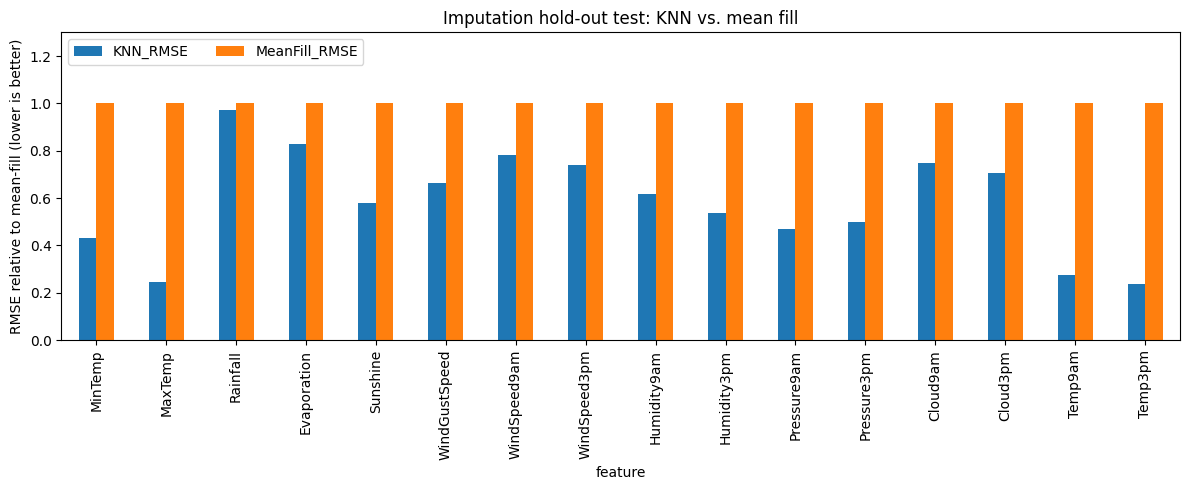

In [13]:
# Hold-out validation: hide 5% of KNOWN values, impute them, and compare with the true values.
# Run on a 20k-row sample so it finishes quickly. Baseline = fill with the column mean.
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(numeric_scaled), size=min(20_000, len(numeric_scaled)), replace=False)
sample = numeric_scaled[idx].copy()

known = ~np.isnan(sample)
hide = known & (rng.random(sample.shape) < 0.05)
masked = sample.copy()
masked[hide] = np.nan

knn_filled = KNNImputer(n_neighbors=KNN_NEIGHBORS, weights="distance",
                        metric="nan_euclidean").fit_transform(masked)
mean_filled = np.where(np.isnan(masked), np.nanmean(masked, axis=0), masked)

rows = []
for j, col in enumerate(numeric_cols):
    m = hide[:, j]
    if m.sum() == 0:
        continue
    scale = scaler.scale_[j]  # back to original units
    truth = sample[m, j] * scale
    rows.append({
        "feature": col,
        "hidden_values": int(m.sum()),
        "KNN_MAE": np.abs(knn_filled[m, j] * scale - truth).mean(),
        "KNN_RMSE": np.sqrt(((knn_filled[m, j] * scale - truth) ** 2).mean()),
        "MeanFill_MAE": np.abs(mean_filled[m, j] * scale - truth).mean(),
        "MeanFill_RMSE": np.sqrt(((mean_filled[m, j] * scale - truth) ** 2).mean()),
    })
validation = pd.DataFrame(rows).set_index("feature").round(3)
validation["RMSE_improvement_%"] = (100 * (1 - validation["KNN_RMSE"] / validation["MeanFill_RMSE"])).round(1)
display(validation)
validation.to_csv(RESULTS_DIR / "imputation_validation.csv")
summary["knn_vs_mean_median_rmse_improvement_pct"] = float(validation["RMSE_improvement_%"].median())

fig, ax = plt.subplots(figsize=(12, 5))
validation[["KNN_RMSE", "MeanFill_RMSE"]].div(validation["MeanFill_RMSE"], axis=0).plot.bar(ax=ax)
ax.set_ylim(0, 1.3)
ax.legend(ncol=2, loc="upper left")
ax.set_ylabel("RMSE relative to mean-fill (lower is better)")
ax.set_title("Imputation hold-out test: KNN vs. mean fill")
plt.tight_layout()
save_fig("07_imputation_validation")
plt.show()

## 10. Categorical imputation and encoding

* **Wind directions:** filled forward then backward **within each station** (rows are sorted by date), so one station never
  borrows another station's wind. Any leftover gaps use the global mode.
  Compass points are circular (N is next to NNW), so they are encoded as `sin`/`cos` of the bearing instead of arbitrary integers.
* **`RainToday`:** by the dataset's definition it is "Yes" when rainfall is at least 1 mm, so missing values are derived from the imputed `Rainfall`.
* **`RainTomorrow`:** mapped to 0/1 (no missing values remain after Section 7).
* **`Location`:** label-encoded (mapping saved). Use one-hot encoding for linear models.

In [14]:
cat_df = weather_df_clean[categorical_cols].copy()

COMPASS = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
wind_features = {}
for col in wind_cols:
    filled = cat_df.groupby(weather_df_clean["Location"])[col].ffill()
    filled = filled.groupby(weather_df_clean["Location"]).bfill()
    filled = filled.fillna(filled.mode()[0])
    angle = filled.map({d: i * 2 * np.pi / 16 for i, d in enumerate(COMPASS)})
    wind_features[f"{col}_sin"] = np.sin(angle)
    wind_features[f"{col}_cos"] = np.cos(angle)
wind_features = pd.DataFrame(wind_features, index=cat_df.index)

rain_today = cat_df["RainToday"].map({"No": 0, "Yes": 1})
rain_today = rain_today.fillna((numeric_filled["Rainfall"] >= 1.0).astype(int)).astype(int)
rain_tomorrow = cat_df["RainTomorrow"].map({"No": 0, "Yes": 1}).astype(int)

le = LabelEncoder()
location_code = pd.Series(le.fit_transform(cat_df["Location"]), index=cat_df.index, name="Location_code")
location_map = {name: int(code) for name, code in zip(le.classes_, le.transform(le.classes_))}
(RESULTS_DIR / "location_encoding.json").write_text(json.dumps(location_map, indent=2))

465

## 11. Assemble, validate and export

In [15]:
weather_df_cleaned = pd.concat(
    [weather_df_clean[["Date", "Location"]], location_code, numeric_filled, wind_features,
     rain_today.rename("RainToday"), rain_tomorrow.rename("RainTomorrow")],
    axis=1,
)

assert weather_df_cleaned.isna().sum().sum() == 0, "NaNs remain in the final table"
assert len(weather_df_cleaned) == len(weather_df_clean)

print("Final shape:", weather_df_cleaned.shape)
balance = weather_df_cleaned["RainTomorrow"].value_counts(normalize=True).mul(100).round(2)
print("\nRainTomorrow class balance (%):")
print(balance.to_string())

summary.update(
    final_rows=int(weather_df_cleaned.shape[0]),
    final_columns=int(weather_df_cleaned.shape[1]),
    rain_tomorrow_yes_pct=float(balance.get(1, 0)),
    rain_tomorrow_no_pct=float(balance.get(0, 0)),
    knn={"n_neighbors": KNN_NEIGHBORS, "weights": "distance", "metric": "nan_euclidean"},
)
weather_df_cleaned.head(10)

Final shape: (75323, 27)

RainTomorrow class balance (%):
RainTomorrow
0    77.78
1    22.22


,Date,Location,Location_code,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,...,Temp9am,Temp3pm,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos,RainToday,RainTomorrow
0,2008-12-01,AliceSprings,0,19.6,37.6,0.0,11.2,9.8,87.0,20.0,...,30.4,37.2,-9.238795e-01,3.826834e-01,3.826834e-01,0.923880,7.071068e-01,7.071068e-01,0,1
1,2008-12-02,AliceSprings,0,21.0,39.1,1.2,9.0,12.2,41.0,24.0,...,32.5,38.2,-3.826834e-01,9.238795e-01,-3.826834e-01,0.923880,1.224647e-16,-1.000000e+00,1,0
2,2008-12-03,AliceSprings,0,22.9,40.9,0.0,11.6,12.6,48.0,7.0,...,35.0,40.4,-3.826834e-01,9.238795e-01,9.238795e-01,0.382683,0.000000e+00,1.000000e+00,0,0
3,2008-12-04,AliceSprings,0,24.7,40.5,0.0,16.0,7.8,72.0,2.0,...,32.3,36.5,-9.238795e-01,3.826834e-01,-3.826834e-01,-0.923880,-1.000000e+00,-1.836970e-16,0,0
4,2008-12-05,AliceSprings,0,23.4,32.4,0.2,12.2,4.1,46.0,9.0,...,26.8,31.1,-3.826834e-01,-9.238795e-01,1.224647e-16,-1.000000,1.224647e-16,-1.000000e+00,0,1
5,2008-12-06,AliceSprings,0,21.7,25.1,2.6,8.4,0.2,35.0,19.0,...,21.9,22.9,3.826834e-01,-9.238795e-01,-3.826834e-01,-0.923880,0.000000e+00,1.000000e+00,1,1
6,2008-12-07,AliceSprings,0,20.9,25.7,4.8,4.6,2.1,31.0,11.0,...,25.0,24.3,0.000000e+00,1.000000e+00,-3.826834e-01,-0.923880,-3.826834e-01,9.238795e-01,1,0
7,2008-12-08,AliceSprings,0,17.7,34.6,0.6,3.0,12.2,26.0,15.0,...,24.5,33.6,1.000000e+00,6.123234e-17,9.238795e-01,0.382683,-3.826834e-01,9.238795e-01,0,0
8,2008-12-09,AliceSprings,0,24.4,39.0,0.0,8.0,11.0,50.0,28.0,...,32.5,38.0,1.224647e-16,-1.000000e+00,0.000000e+00,1.000000,-9.238795e-01,3.826834e-01,0,0
9,2008-12-10,AliceSprings,0,25.3,38.6,0.0,11.8,8.7,54.0,22.0,...,32.8,29.6,-1.000000e+00,-1.836970e-16,3.826834e-01,0.923880,-9.238795e-01,-3.826834e-01,0,0


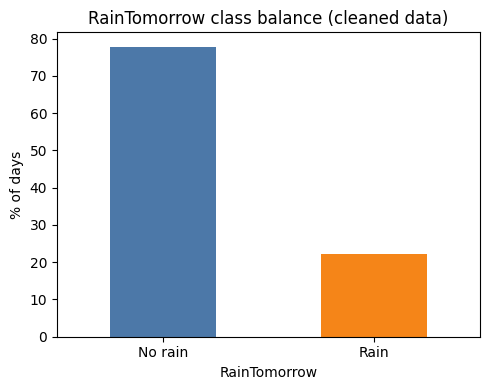

Saved cleaned data and results/preprocessing_summary.json


In [16]:
# Class balance and missing-data rows are plotted so the model-ready table is easy to review
fig, ax = plt.subplots(figsize=(5, 4))
balance.rename({0: "No rain", 1: "Rain"}).plot.bar(ax=ax, rot=0, color=["#4c78a8", "#f58518"])
ax.set_ylabel("% of days")
ax.set_title("RainTomorrow class balance (cleaned data)")
plt.tight_layout()
save_fig("08_class_balance")
plt.show()

weather_df_cleaned.to_csv(OUT_DIR / "weatherAUS_cleaned.csv", index=False)
(RESULTS_DIR / "preprocessing_summary.json").write_text(json.dumps(summary, indent=2))
print("Saved cleaned data and results/preprocessing_summary.json")

## 12. Modeling: will it rain tomorrow?

Evaluation is set up to avoid the usual mistakes:

* **Time-ordered split.** Train on everything **before 2016-01-01**, test on 2016 onward. A random split would let the model see
  days right before and after each test day, which overstates real forecasting skill.
* **No leakage.** The scaler and KNN imputer are fitted on the training period only (using a random 30,000-row donor sample so it
  runs in minutes), then applied to the test period.
* **Honest baselines.** "Always predict no rain" and "tomorrow = today" (persistence) are included, because with ~22% rainy days
  plain accuracy is easy to inflate.
* **Imputation vs. no imputation.** Gradient boosting can handle missing values natively, so it is also trained on the raw,
  unimputed features to test whether KNN imputation is actually worth it.

Metrics are reported for the rain class at a 0.5 threshold, plus threshold-free ROC-AUC and PR-AUC.

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
import time

model_df = weather_df_clean.reset_index(drop=True)          # kept stations, labelled rows, sorted by station and date
y = model_df["RainTomorrow"].map({"No": 0, "Yes": 1}).astype(int).to_numpy()

# ---- features (NaNs are kept here; imputation happens after the split) ----
X = model_df[numeric_cols].copy()
for col in wind_cols:
    filled = model_df.groupby("Location")[col].ffill()      # carry past readings forward only: nothing from the future
    angle = filled.map({d: i * 2 * np.pi / 16 for i, d in enumerate(COMPASS)})
    X[f"{col}_sin"], X[f"{col}_cos"] = np.sin(angle), np.cos(angle)
doy = model_df["Date"].dt.dayofyear
X["season_sin"], X["season_cos"] = np.sin(2 * np.pi * doy / 365.25), np.cos(2 * np.pi * doy / 365.25)
station_dummies = pd.get_dummies(model_df["Location"], dtype=float)

CUTOFF = pd.Timestamp("2016-01-01")
train_mask = (model_df["Date"] < CUTOFF).to_numpy()
test_mask = ~train_mask
y_train, y_test = y[train_mask], y[test_mask]
print(f"Train: {train_mask.sum():,} rows ({model_df.loc[train_mask, 'Date'].min().date()} to {model_df.loc[train_mask, 'Date'].max().date()}), "
      f"rain on {100 * y_train.mean():.1f}% of days")
print(f"Test : {test_mask.sum():,} rows ({model_df.loc[test_mask, 'Date'].min().date()} to {model_df.loc[test_mask, 'Date'].max().date()}), "
      f"rain on {100 * y_test.mean():.1f}% of days")
summary["split"] = dict(cutoff=str(CUTOFF.date()), train_rows=int(train_mask.sum()), test_rows=int(test_mask.sum()),
                        train_rain_pct=float(100 * y_train.mean()), test_rain_pct=float(100 * y_test.mean()))

Train: 62,133 rows (2007-11-01 to 2015-12-31), rain on 22.1% of days
Test : 13,190 rows (2016-01-01 to 2017-06-25), rain on 23.0% of days


In [18]:
# ---- Variant A: KNN-imputed features, imputer fitted on the training period only ----
scaler_m = StandardScaler().fit(X[train_mask])
Xs_train, Xs_test = scaler_m.transform(X[train_mask]), scaler_m.transform(X[test_mask])

rng = np.random.default_rng(RANDOM_STATE)
donors = rng.choice(len(Xs_train), size=min(30_000, len(Xs_train)), replace=False)
knn_m = KNNImputer(n_neighbors=KNN_NEIGHBORS, weights="distance", metric="nan_euclidean").fit(Xs_train[donors])

t0 = time.time()
Xi_train, Xi_test = transform_in_chunks(knn_m, Xs_train), transform_in_chunks(knn_m, Xs_test)
assert Xi_train.shape == Xs_train.shape, "imputer dropped a column"
print(f"KNN imputation of train + test took {time.time() - t0:.0f}s")

def to_frame(Xi, mask):
    df = pd.DataFrame(scaler_m.inverse_transform(Xi), columns=X.columns, index=model_df.index[mask])
    df["RainToday_derived"] = (df["Rainfall"] >= 1.0).astype(float)
    return pd.concat([df, station_dummies[mask]], axis=1)

XA_train, XA_test = to_frame(Xi_train, train_mask), to_frame(Xi_test, test_mask)

# ---- Variant B: raw features with NaNs left in place (for models that handle them natively) ----
XB = X.copy()
XB["RainToday_derived"] = (XB["Rainfall"] >= 1.0).astype(float).where(XB["Rainfall"].notna())
XB = pd.concat([XB, station_dummies], axis=1)
XB_train, XB_test = XB[train_mask], XB[test_mask]
print("Feature count:", XA_train.shape[1])

KNN imputation of train + test took 42s
Feature count: 50


In [19]:
def evaluate(name, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {"model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, proba),
            "pr_auc": average_precision_score(y_test, proba)}

fitted, probas = {}, {}

probas["Always predict 'no rain'"] = DummyClassifier(strategy="prior").fit(XA_train, y_train).predict_proba(XA_test)[:, 1]
probas["Persistence (tomorrow = today)"] = XA_test["RainToday_derived"].to_numpy()

lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
lr.fit(XA_train, y_train)
fitted["Logistic regression (KNN-imputed)"] = (lr, XA_test)

hgb_a = HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE).fit(XA_train, y_train)
fitted["Gradient boosting (KNN-imputed)"] = (hgb_a, XA_test)

hgb_b = HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE).fit(XB_train, y_train)
fitted["Gradient boosting (raw NaNs, no imputation)"] = (hgb_b, XB_test)

for name, (est, Xt) in fitted.items():
    probas[name] = est.predict_proba(Xt)[:, 1]

results = pd.DataFrame([evaluate(n, p) for n, p in probas.items()]).set_index("model")
display(results.round(3))
results.round(4).to_csv(RESULTS_DIR / "model_comparison.csv")
summary["model_results"] = results.round(4).to_dict(orient="index")

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Always predict 'no rain',0.770,0.000,0.000,0.000,0.500,0.230
Persistence (tomorrow = today),0.745,0.449,0.474,0.461,0.650,0.334
Logistic regression (KNN-imputed),0.790,0.530,0.786,0.633,0.869,0.699
Gradient boosting (KNN-imputed),0.800,0.544,0.805,0.649,0.883,0.734
"Gradient boosting (raw NaNs, no imputation)",0.807,0.557,0.794,0.655,0.885,0.735


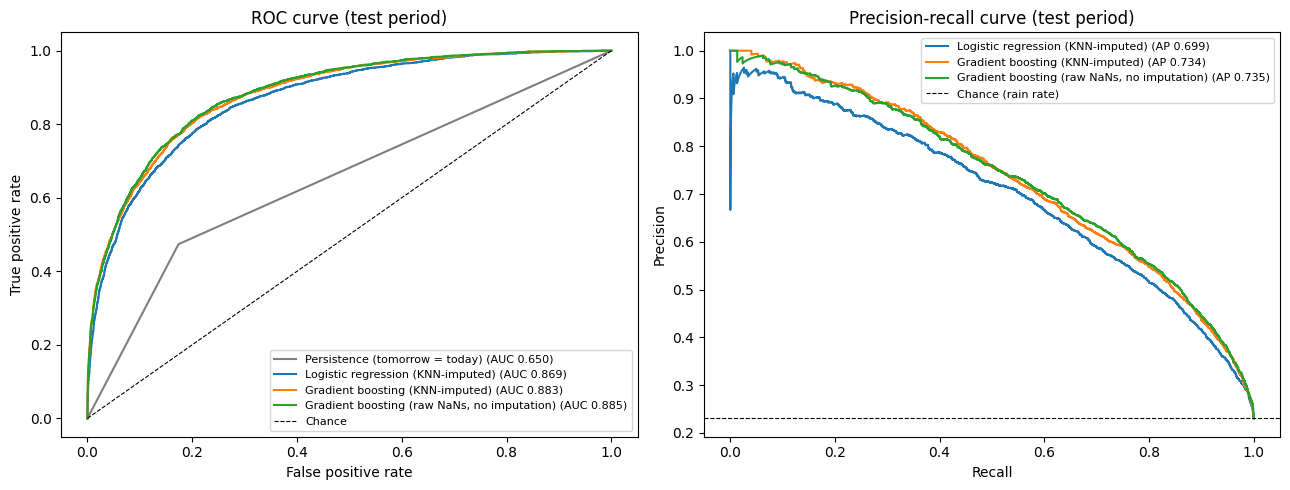

In [20]:
# ROC and precision-recall curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = dict(zip([n for n in probas if not n.startswith("Always")], ["#7f7f7f", "#1f77b4", "#ff7f0e", "#2ca02c"]))
for name, p in probas.items():
    if name.startswith("Always"):
        continue
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=palette[name], label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})")
    if not name.startswith("Persistence"):
        pr, rc, _ = precision_recall_curve(y_test, p)
        axes[1].plot(rc, pr, color=palette[name], label=f"{name} (AP {average_precision_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve (test period)")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", linewidth=0.8, label="Chance (rain rate)")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve (test period)")
for a in axes:
    a.legend(fontsize=8, loc="best")
plt.tight_layout()
save_fig("09_roc_pr_curves")
plt.show()

Best model by ROC-AUC: Gradient boosting (raw NaNs, no imputation)


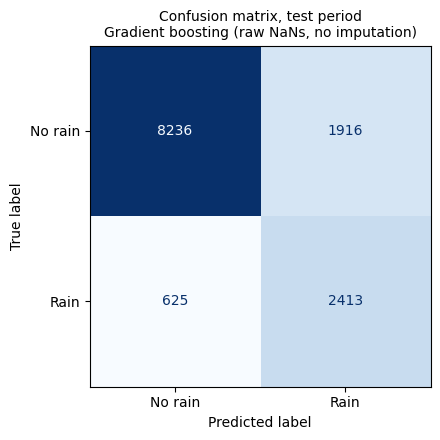

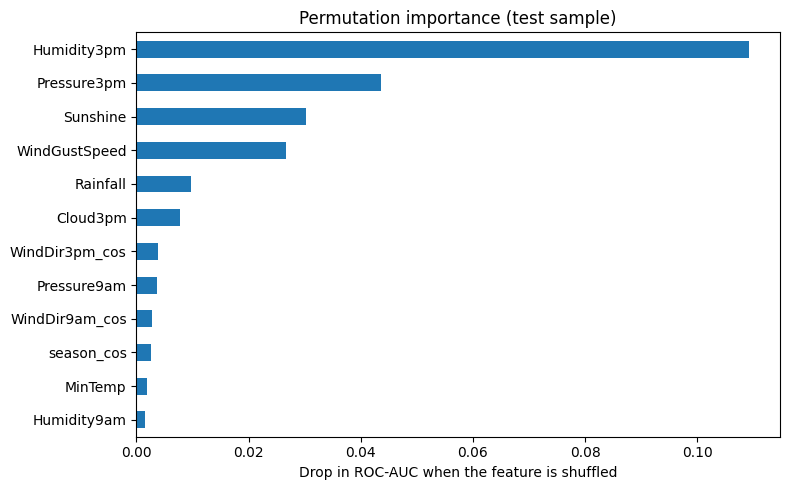

In [21]:
# Confusion matrix and feature importance for the best model by ROC-AUC
best_name = results.drop(index=[i for i in results.index if i.startswith(("Always", "Persistence"))])["roc_auc"].idxmax()
best_est, best_X = fitted[best_name]
summary["best_model"] = best_name
print("Best model by ROC-AUC:", best_name)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, (probas[best_name] >= 0.5).astype(int), display_labels=["No rain", "Rain"],
                                        cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix, test period\n{best_name}", fontsize=10)
plt.tight_layout()
save_fig("10_confusion_matrix")
plt.show()

sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(best_X), size=min(8000, len(best_X)), replace=False)
perm = permutation_importance(best_est, best_X.iloc[sample_idx], y_test[sample_idx], scoring="roc_auc",
                              n_repeats=5, random_state=RANDOM_STATE)
imp = pd.Series(perm.importances_mean, index=best_X.columns).sort_values(ascending=False)
imp = imp[~imp.index.isin(station_dummies.columns)].head(12)       # hide the per-station dummies for readability
fig, ax = plt.subplots(figsize=(8, 5))
imp[::-1].plot.barh(ax=ax)
ax.set_xlabel("Drop in ROC-AUC when the feature is shuffled")
ax.set_title("Permutation importance (test sample)")
plt.tight_layout()
save_fig("11_feature_importance")
plt.show()
imp.round(4).to_csv(RESULTS_DIR / "feature_importance.csv")
summary["top_features"] = imp.round(4).head(8).to_dict()

In [22]:
# Rewrite the summary with the modeling metrics included
(RESULTS_DIR / "preprocessing_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps({k: summary[k] for k in ("split", "best_model", "top_features")}, indent=2))

{
  "split": {
    "cutoff": "2016-01-01",
    "train_rows": 62133,
    "test_rows": 13190,
    "train_rain_pct": 22.051083965042732,
    "test_rain_pct": 23.03260045489007
  },
  "best_model": "Gradient boosting (raw NaNs, no imputation)",
  "top_features": {
    "Humidity3pm": 0.1093,
    "Pressure3pm": 0.0436,
    "Sunshine": 0.0302,
    "WindGustSpeed": 0.0267,
    "Rainfall": 0.0097,
    "Cloud3pm": 0.0078,
    "WindDir3pm_cos": 0.0039,
    "Pressure9am": 0.0037
  }
}


## Possible extensions

* Tune hyperparameters with a time-aware cross-validation (e.g. `TimeSeriesSplit`).
* Choose the decision threshold to match a use case (a missed rain day and a false alarm rarely cost the same).
* Add lagged features (yesterday's pressure change, rainfall over the last 3 days) per station.
* Report performance per station to see where the model is weakest.